# Advanced Visualization with VISTA

This notebook demonstrates advanced plotting and visualization options available in the mcda-vista library. You will learn how to customize individual vistas, embed them in multi-panel figures, build comparison and facet grids, work with the built-in colormap, and export publication-quality figures.

In [1]:
%matplotlib inline

from mcda_vista import (
    generate_vista,
    plot_vista,
    plot_vista_grid,
    plot_vista_comparison,
    VistaResult,
    Relation,
)
from mcda_vista.plotting import vista_colormap
from mcda_vista.methods import get_method
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

## 1. Generate Sample Data

We generate VISTA results for three methods: TOPSIS, Electre III, and PROMETHEE I. We will use these results for the example visualizations.

In [2]:
result_topsis = generate_vista("topsis", resolution=51)
result_electre = generate_vista("electre_iii", resolution=51, q=0.10, p=0.20, v=1.0, alpha=-0.15, beta=0.30)
result_promethee = generate_vista("promethee_i", resolution=51, f="t4", q=0.10, p=0.20, s=0.0)

print(f"TOPSIS:     {result_topsis.relations.shape[0]:,} grid points")
print(f"Electre III: {result_electre.relations.shape[0]:,} grid points")
print(f"PROMETHEE I: {result_promethee.relations.shape[0]:,} grid points")

VISTA (promethee_i): 100%|███████████████████████████████████████████████████████| 2601/2601 [00:00<00:00, 8381.56pt/s]

TOPSIS:     2,601 grid points
Electre III: 2,601 grid points
PROMETHEE I: 2,601 grid points


## 2. Single Plot Customization

`plot_vista()` accepts several keyword arguments that let you control axis labels, titles, point size, and whether the reference point and legend are displayed.

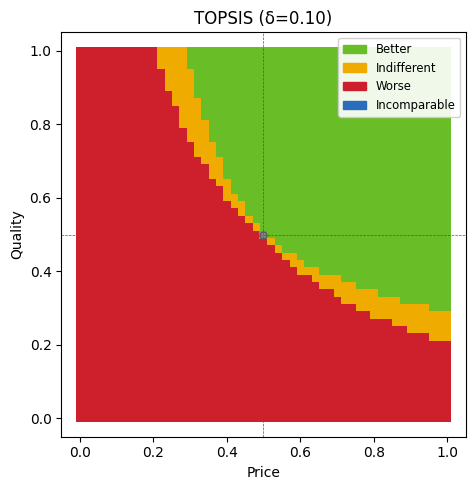

In [7]:
# Full customization: labels, title, larger points, reference marker, legend
fig = plot_vista(
    result_topsis,
    xlabel="Price",
    ylabel="Quality",
    title="TOPSIS (δ=0.10)",
    point_size=27,
    show_reference=True,
    show_legend=True,
)

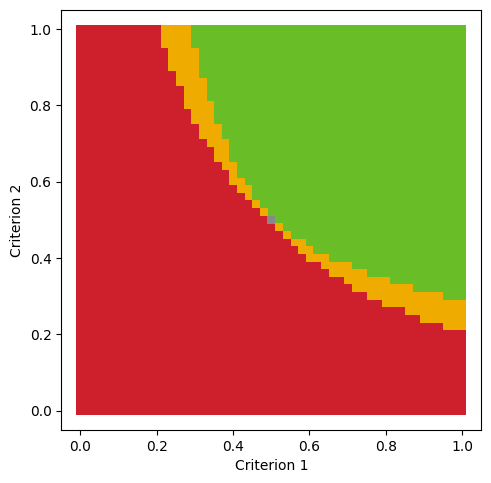

In [8]:
# Minimal plot: no legend, no reference marker — useful for insets or thumbnails
fig = plot_vista(
    result_topsis,
    show_legend=False,
    show_reference=False,
    point_size=27,
)

## 3. Embedding in Custom Figures

Pass an existing `Axes` object via the `ax` parameter to embed a vista inside any matplotlib layout. This is ideal when you need a shared legend or want to combine VISTA maps with other chart types.

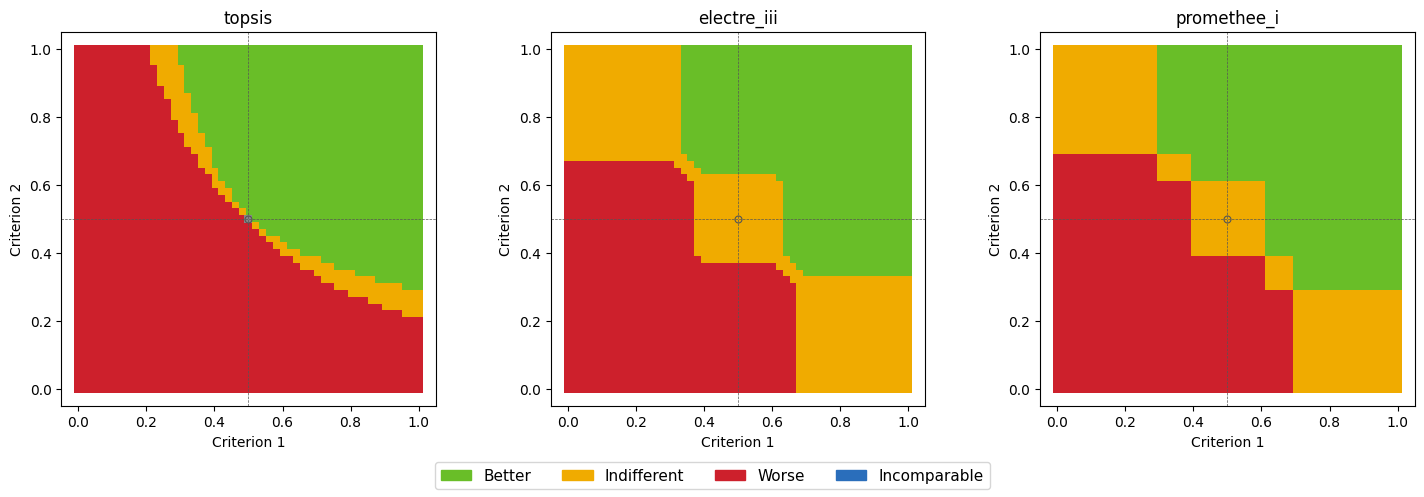

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, result in zip(axes, [result_topsis, result_electre, result_promethee]):
    plot_vista(result, ax=ax, title=result.method_name, show_legend=False, point_size=27)

# Single shared legend at the bottom
handles = [
    mpatches.Patch(color=c, label=l)
    for l, c in [
        ("Better", "#69be28"),
        ("Indifferent", "#f0ab00"),
        ("Worse", "#cd202c"),
        ("Incomparable", "#2a6ebb"),
    ]
]
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=11)
fig.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

## 4. Comparison Plots

`plot_vista_comparison()` arranges a flat list of results in a facet-wrap layout. The `ncols` parameter controls how many columns per row.

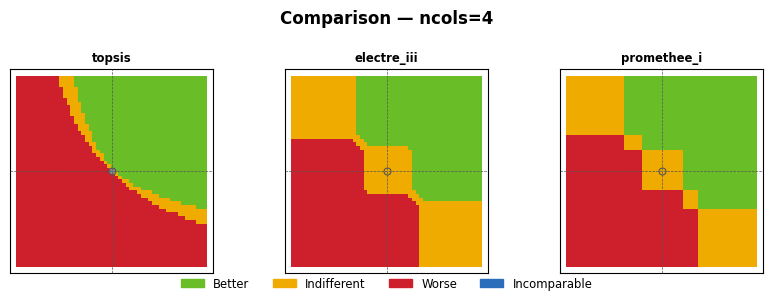

In [14]:
all_results = [result_topsis, result_electre, result_promethee]

# Wide layout: 4 columns (all fit in one row here)
fig = plot_vista_comparison(all_results, ncols=4, title="Comparison — ncols=4", point_size=17)
plt.show()

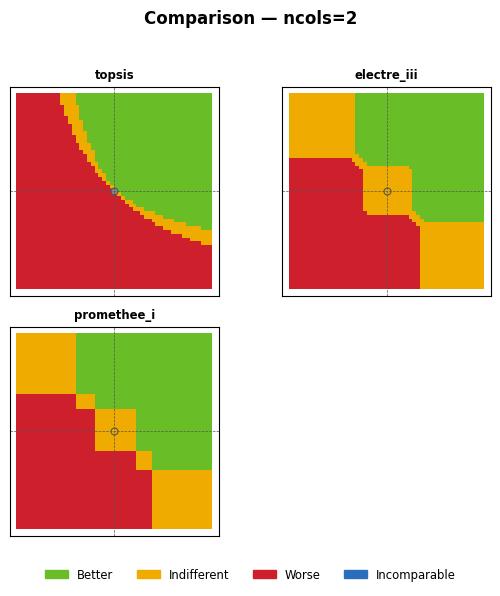

In [15]:
# Narrow layout: 2 columns (wraps to multiple rows)
fig = plot_vista_comparison(all_results, ncols=2, title="Comparison — ncols=2", point_size=17)
plt.show()

## 5. Grid Plots (Facet Grid)

`plot_vista_grid()` creates a matrix of subplots where rows and columns correspond to experimental factors — for example, different methods × different parameter values. Here we vary the `delta` threshold for TOPSIS and SAW.

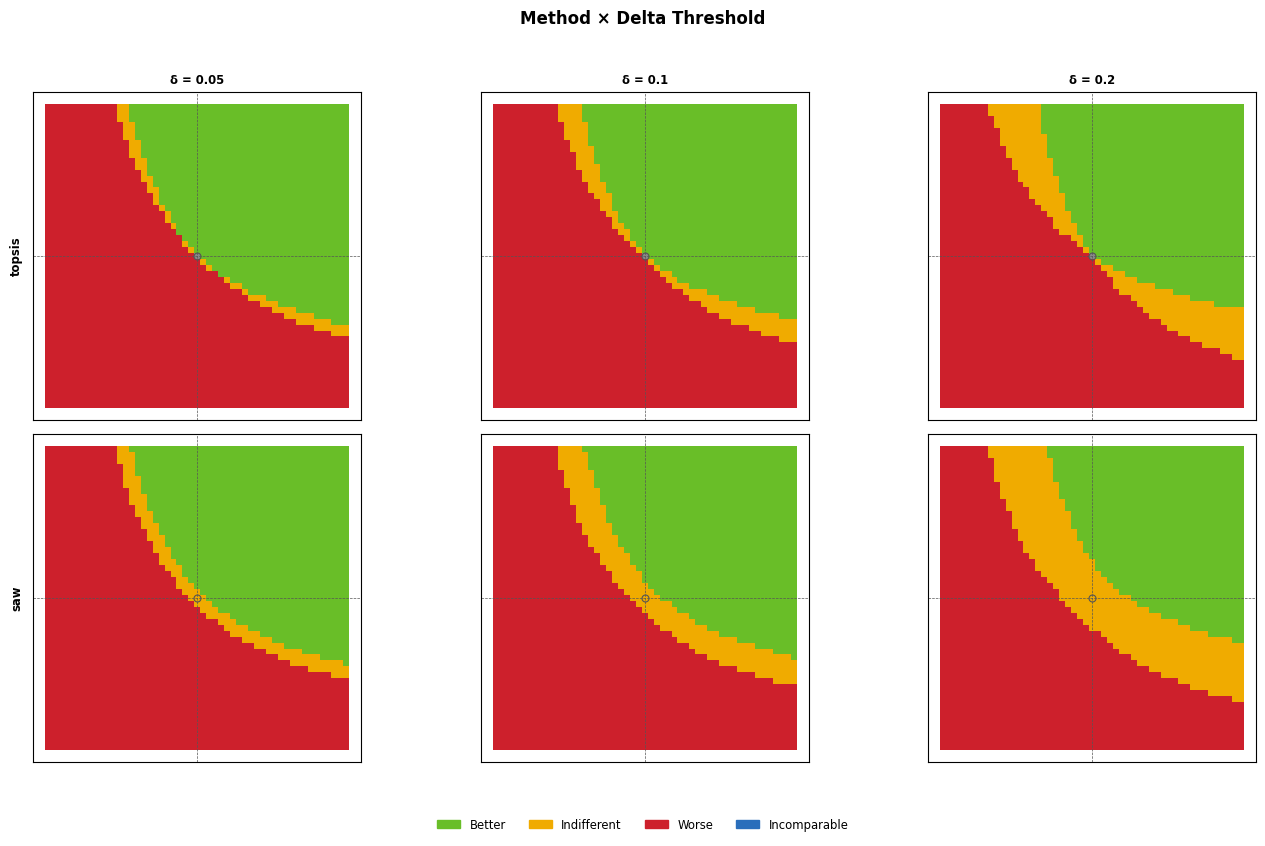

In [19]:
deltas = [0.05, 0.10, 0.20]
methods = ["topsis", "saw"]

grid_results: list[list[VistaResult]] = []
for method in methods:
    row = []
    for delta in deltas:
        r = generate_vista(method, resolution=51, delta=delta, progress=False)
        row.append(r)
    grid_results.append(row)

fig = plot_vista_grid(
    grid_results,
    row_labels=methods,
    col_labels=[f"δ = {d}" for d in deltas],
    title="Method × Delta Threshold",
    figsize=(14, 8),
    point_size=15
)
plt.show()

## 6. Working with the Colormap

The VISTA color scheme is accessible via `vista_colormap()` (or `Relation.color_map()`). You can reuse these colors in any matplotlib plot to keep a consistent visual language.

In [20]:
cmap = vista_colormap()
print("vista_colormap():")
for value, color in sorted(cmap.items()):
    print(f"  {Relation(value).label:15s} (value={value}) → {color}")

print("\nRelation.color_map():")
print(Relation.color_map())

vista_colormap():
  Error           (value=0) → #888888
  Worse           (value=1) → #cd202c
  Indifferent     (value=2) → #f0ab00
  Better          (value=3) → #69be28
  Incomparable    (value=4) → #2a6ebb

Relation.color_map():
{0: '#888888', 1: '#cd202c', 2: '#f0ab00', 3: '#69be28', 4: '#2a6ebb'}


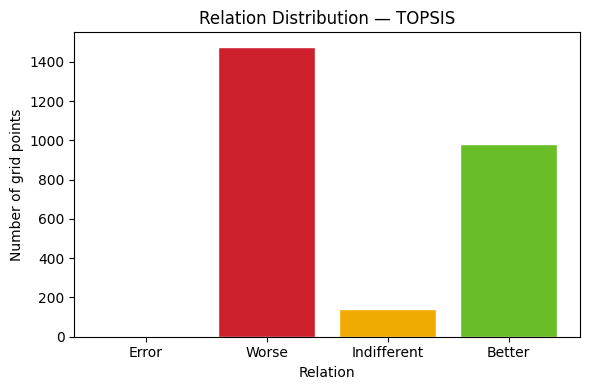

In [21]:
# Bar chart of relation counts using VISTA colors
cmap = vista_colormap()
unique, counts = np.unique(result_topsis.relations, return_counts=True)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    [Relation(u).label for u in unique],
    counts,
    color=[cmap[u] for u in unique],
    edgecolor="white",
)
ax.set_title("Relation Distribution — TOPSIS")
ax.set_ylabel("Number of grid points")
ax.set_xlabel("Relation")
plt.tight_layout()
plt.show()

## 7. Combined Panels

Here we put a vista on the left and a distribution bar chart on the right.

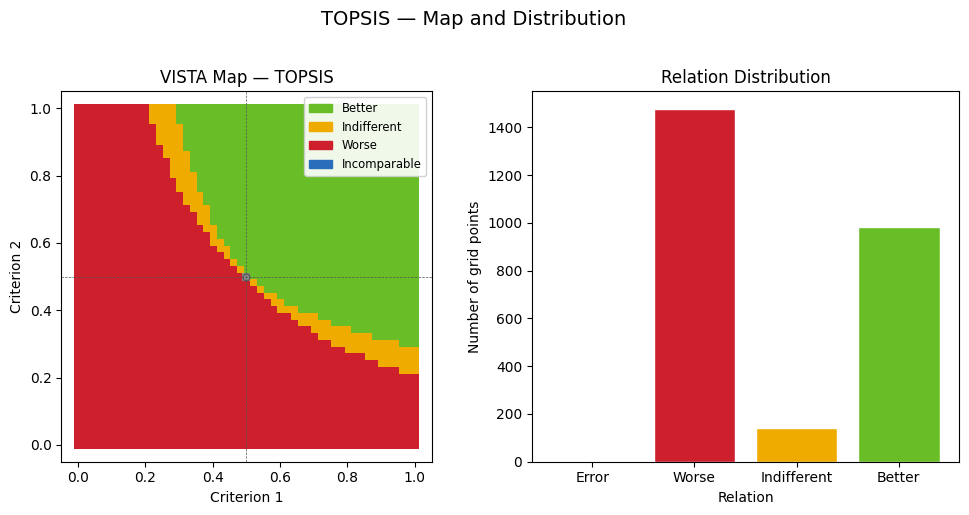

In [23]:
fig = plt.figure(figsize=(10, 5))

# Left panel: VISTA map
ax1 = fig.add_subplot(1, 2, 1)
plot_vista(result_topsis, ax=ax1, title="VISTA Map — TOPSIS", show_legend=True, point_size=27)

# Right panel: relation distribution
ax2 = fig.add_subplot(1, 2, 2)
cmap = vista_colormap()
unique, counts = np.unique(result_topsis.relations, return_counts=True)
ax2.bar(
    [Relation(u).label for u in unique],
    counts,
    color=[cmap[u] for u in unique],
    edgecolor="white",
)
ax2.set_title("Relation Distribution")
ax2.set_ylabel("Number of grid points")
ax2.set_xlabel("Relation")

fig.suptitle("TOPSIS — Map and Distribution", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 8. Saving Figures

Use `fig.savefig()` to export figures in raster (PNG) or vector (PDF/SVG) formats.

Saved: vista_publication.png, vista_publication.pdf


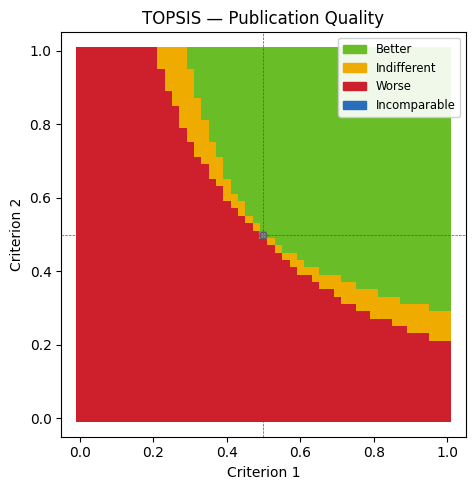

In [24]:
fig = plot_vista(
    result_topsis,
    title="TOPSIS — Publication Quality",
    point_size=27,
)

# Raster export
fig.savefig("vista_publication.png", dpi=300, bbox_inches="tight")

# Vector export
fig.savefig("vista_publication.pdf", bbox_inches="tight")

print("Saved: vista_publication.png, vista_publication.pdf")

## Summary

This notebook covered the full range of visualization tools in mcda-vista:

| Technique | Function / Approach |
|-----------|--------------------|
| Single-map customization | `plot_vista(…, xlabel, ylabel, title, point_size, show_reference, show_legend)` |
| Embedding in custom layouts | `plot_vista(…, ax=existing_axes)` |
| Side-by-side comparisons | `plot_vista_comparison(results, ncols=…)` |
| Facet grids (method × param) | `plot_vista_grid(results_2d, row_labels, col_labels)` |
| Accessing colors | `vista_colormap()`, `Relation.color_map()`, `Relation(v).color` |
| Combined panels | Standard matplotlib + `plot_vista(…, ax=…)` |
| Export | `fig.savefig("name.png", dpi=300, bbox_inches="tight")` |

For best results, use `resolution=101` (or higher) for final figures and `resolution=51` for quick iteration.